# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [ ]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
#df = pd.read_csv('Exercise7BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


How many rows and columns does the dataset contain?

In [ ]:
df.shape

(17379, 17)

Are any of the columns missing values?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

** Code modified to include new combined interaction features:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target = 'cnt'
#features = [
#    'temp','atemp','hum','windspeed','weathersit',
#    'hr','weekday','workingday','holiday','season','yr'
#]

# Create new interaction features directly in the DataFrame
df['hr_workingday'] = df['hr'] * df['workingday']
df['temp_hum'] = df['temp'] * df['hum']
df['weather_hum'] = df['weathersit'] * df['hum']

# Update the features list to include both new interaction columns
features = [
    'temp', 'atemp', 'hum', 'windspeed', 'weathersit',
    'hr', 'weekday', 'workingday', 'holiday', 'season', 'yr',
    'hr_workingday', 'temp_hum', 'weather_hum'
]

X = df[features].copy()
y = df[target].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [ ]:
# A super-fast baseline, just for context
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Import the direct root mean squared error function introduced in recent scikit-learn versions
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

#rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)

# Calculate RMSE cleanly without deprecated arguments
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': 138.35796425518902, 'LR_MAE': 103.43906833895811, 'LR_R2': 0.39546257367575366}


## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [ ]:
#pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model, which is a linear stack of layers.
model = Sequential()
# Add a Dense layer with 32 units, ReLU activation, and an input dimension of 11.
model.add(Dense(32, activation='relu', input_dim=11))
# Add another Dense layer with 64 units and ReLU activation.
model.add(Dense(64, activation='relu'))
# Add a final Dense layer with 1 unit (typically used for regression tasks).
model.add(Dense(1))
# Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# and MAE metric to be used during training.
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
# Display a summary of the model architecture, including the number of parameters.
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training and prediction
We split the dataset into a training and a test dataset. Then, we fit the neural network model with the training dataset and predict the values for the test dataset.

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 141.1444 - mae: 141.1444 - val_loss: 100.5861 - val_mae: 100.5861
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 100.3751 - mae: 100.3751 - val_loss: 98.5407 - val_mae: 98.5407
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 99.0960 - mae: 99.0960 - val_loss: 97.5644 - val_mae: 97.5644
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 98.1260 - mae: 98.1260 - val_loss: 96.6678 - val_mae: 96.6678
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 96.9835 - mae: 96.9835 - val_loss: 95.3472 - val_mae: 95.3472
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 95.3380 - mae: 95.3380 - val_loss: 93.5515 - val_mae: 93.5515
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 93.3030 - mae: 93.3030 - val_loss: 91.4934 - val_mae: 91.4934
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 91.1287 - mae: 91.1287 - val_loss: 89.3645 - val_mae: 89.3645
Epoch 9/20

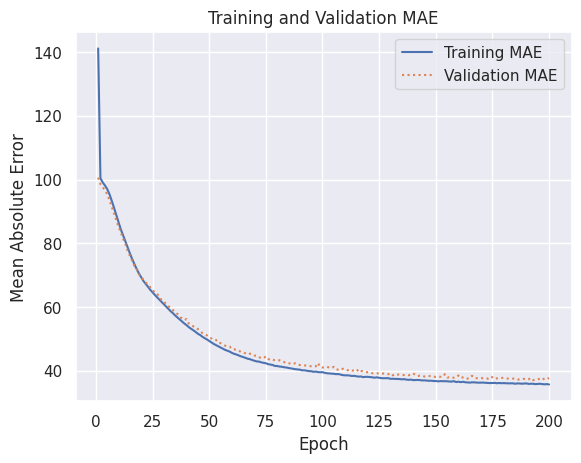

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model to the training data, specifying validation split, epochs, and batch size.
hist = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32)
# Set the style of the plots using Seaborn.
sns.set()
# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist.history['mae']
val_err = hist.history['val_mae']
# Define the number of epochs.
epochs = range(1, len(err) + 1)
# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()
# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

## Evaluate the model
You can evaluate the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), or R-squared (R2).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import the direct root mean squared error function introduced in recent scikit-learn versions
from sklearn.metrics import root_mean_squared_error

# Calculate the Mean Absolute Error (MAE) between the true and predicted values.
mae_nn = mean_absolute_error(y_test, y_pred)
# Calculate the Root Mean Squared Error (RMSE) between the true and predicted values.
mse_nn = mean_squared_error(y_test, y_pred)
#rmse_nn = mean_squared_error(y_test, y_pred, squared=False)

# Calculate RMSE cleanly without deprecated arguments
rmse_nn = root_mean_squared_error(y_test, y_pred)

# Calculate the R-squared (R2) score, a measure of how well the model explains the variance in the data.
r2_nn = r2_score(y_test, y_pred)
# Print the calculated metrics.
print(f"Mean Absolute Error of NN: {mae_nn}")
print(f"Root Mean Squared Error of NN: {rmse_nn}")
print(f"R-squared of NN: {r2_nn}")

Mean Absolute Error of NN: 36.57340537705025
Root Mean Squared Error of NN: 61.62573659124267
R-squared of NN: 0.8800668852818325


## Compare Metrics (optional)
we compare the performance of NN with baseline linear regression.

In [ ]:
import pandas as pd
results = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr},
    {'Model': 'Neural Net', 'RMSE': rmse_nn, 'MAE': mae_nn, 'R2': r2_nn},
])
results

,Model,RMSE,MAE,R2
0,Linear Regression,139.209601,104.795771,0.387997
1,Neural Net,61.625737,36.573405,0.880067


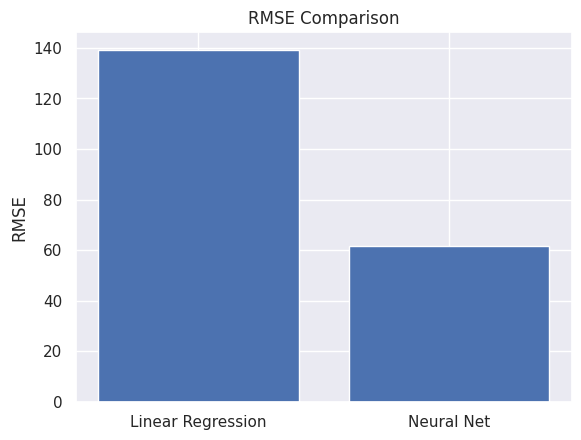

In [ ]:
# Bar chart of RMSE
plt.figure()
plt.bar(results['Model'], results['RMSE'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.show()

# **Task 2: Practical NN training techniques**
The task will illustrate some useful NN training techniques, including saving and loading the trained model, using the callback function to save the best model, and adding dropout layers.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_mae improved from None to 101.61980, saving model to weights.best.keras

Epoch 1: finished saving model to weights.best.keras

Epoch 2: val_mae improved from 101.61980 to 97.98014, saving model to weights.best.keras

Epoch 2: finished saving model to weights.best.keras

Epoch 3: val_mae improved from 97.98014 to 96.94238, saving model to weights.best.keras

Epoch 3: finished saving model to weights.best.keras

Epoch 4: val_mae improved from 96.94238 to 96.16005, saving model to weights.best.keras

Epoch 4: finished saving model to weights.best.keras

Epoch 5: val_mae improved from 96.16005 to 95.16428, saving model to weights.best.keras

Epoch 5: finished saving model to weights.best.keras

Epoch 6: val_mae improved from 95.16428 to 94.14684, saving model to weights.best.keras

Epoch 6: finished saving model to weights.best.keras

Epoch 7: val_mae improved from 94.14684 to 92.37524, saving model to weights.best.keras

Epoch 7: finished saving model to weights.best.keras



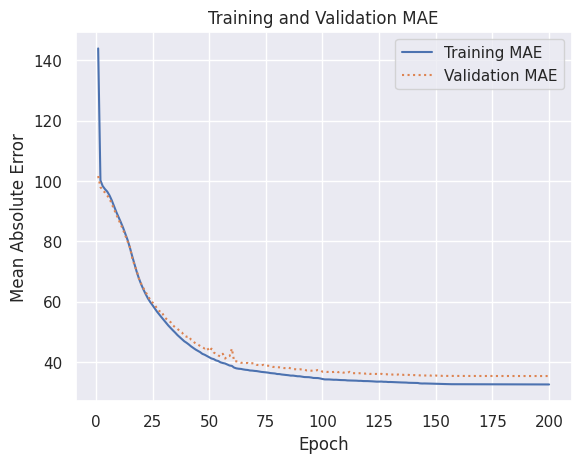

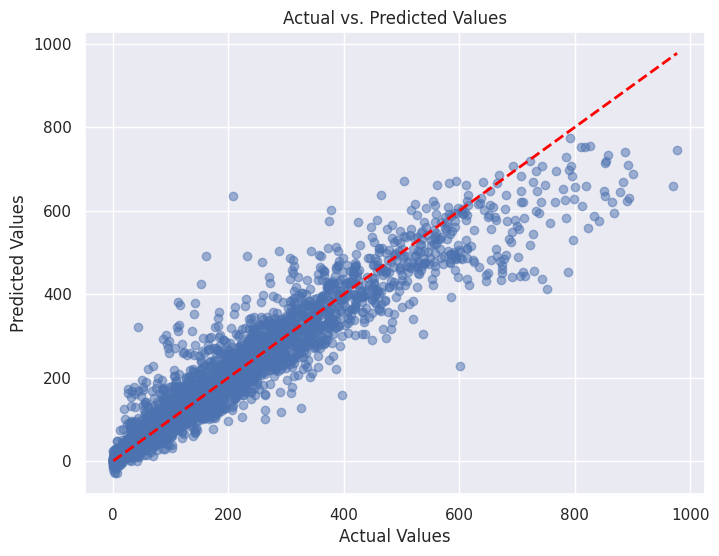

In [ ]:
from json import load
import pandas as pd
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model

#-------------------------------------------------data preprocessing------------------------------------------------------------------


#-------------------------------------------------network construction-----------------------------------------------------------------

#************************************************Here you can choose to add the dropout layer or not***************************
#
def construct_network_model(input_features_count):
# Create a Sequential model, which is a linear stack of layers.
  model = Sequential()

  # Add a Dense layer with 32 units, ReLU activation, and an input dimension of 4.
  model.add(Dense(64, activation='relu', input_dim=input_features_count))

  #  Add a Dropout layer with a dropout rate of 0.5.
  #model.add(Dropout(0.2))

  # Add another Dense layer with 64 units and ReLU activation.
  model.add(Dense(32, activation='relu'))

  # Add another Dropout layer with a dropout rate of 0.5.
  #model.add(Dropout(0.2))

  # Add a final Dense layer with 1 unit (typically used for regression tasks).
  model.add(Dense(1))
  return model

model=construct_network_model(X_train_scaled.shape[1])
# Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# and MAE metric to be used during training.
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
#************************************************Here you can choose to add the dropout layer or not*****************

#-------------------------------------------------model train------------------------------------------------------------------
# use the callback function to early stop, learning rate ajusting, save the best model
# Create an EarlyStopping callback to monitor the validation mean absolute error (val_mae).
# It will stop training if val_mae doesn't improve for 5 consecutive epochs and restores the best weights.
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

# Create a ReduceLROnPlateau callback to monitor val_mae.
# It reduces the learning rate by a factor of 0.5 if val_mae doesn't improve for 3 consecutive epochs.
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)

# Define the file path where the best model will be saved.
filepath = "weights.best.keras"

# Create a ModelCheckpoint callback to monitor the validation mae (val_mae).
# The callback will save thhe model's weights only if the validation mae improves.
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# Train the model using the fit method.
hist_2 = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=0)


#-------------------------------------------------model evaluation--------------------------------------------------------------------

# Set the style of the plots using Seaborn.
sns.set()

# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']

# Define the number of epochs.
epochs = range(1, len(err) + 1)

# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--------------------------------------'+'this is result of the trained model'+"---------------------------------------------")
# Print the calculated metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

#-------------------------------------------------load model and evaluation--------------------------------------------------------------------
if not filepath =="":
  # Load a pre-trained model from the specified file path.
  model = load_model(filepath)

  # Use the loaded model to predict on the test data.
  y_pred = model.predict(X_test_scaled)

  # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print('--------------------------------------'+'this is result of the model loaded from the local path'+"---------------------------------------------")

  # Print the calculated metrics.
  print(f"Mean Absolute Error: {mae}")
  print(f"Mean Squared Error: {mse}")
  print(f"R-squared: {r2}")



  # Create a scatter plot to visualize the relationship
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

  # Add labels and title
  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title("Actual vs. Predicted Values")

  # Add a diagonal line for reference (perfect predictions)
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

  # Show the plot
  plt.show()


--------------------------------------this is result of the trained model---------------------------------------------
Mean Absolute Error: 33.06449572243315
Mean Squared Error: 2926.1082537654625
R-squared: 0.907592918257891
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--------------------------------------this is result of the model loaded from the local path---------------------------------------------
Mean Absolute Error: 33.06449572243315
Mean Squared Error: 2926.1082537654625
R-squared: 0.907592918257891

# **Task 3: Compare the results with a linear regression model**
The task involves comparing the results obtained from the neural network with those from the linear regression model, and we should analyze the reasons behind any differences in the outcomes.

In [ ]:
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Import the direct root mean squared error function introduced in recent scikit-learn versions
from sklearn.metrics import root_mean_squared_error

# Set the style of the plots using seaborn.
sns.set()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
mae = mean_absolute_error(y_test, y_pred)

#rmse = mean_squared_error(y_test, y_pred, squared=False)

# Calculate RMSE cleanly without deprecated arguments
rmse = root_mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print('--------------------------------------'+'this is result of the neural network model'+"---------------------------------------------")
# Print the evaluation metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


# Create a Linear Regression model
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test, y_pred_linear)

#rmse_linear = mean_squared_error(y_test, y_pred_linear, squared=False)

# Calculate RMSE cleanly without deprecated arguments
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print('--------------------------------------'+'this is result of the linear regression model'+"---------------------------------------------")
print(f"Mean Absolute Error of linear model: {mae_linear}")
print(f"Root Mean Squared Error of linear model: {rmse_linear}")
print(f"R-squared of linear model: {r2_linear}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--------------------------------------this is result of the neural network model---------------------------------------------
Mean Absolute Error: 33.485976345292684
Root Mean Squared Error: 54.9346453221936
R-squared: 0.9046967928314651
--------------------------------------this is result of the linear regression model---------------------------------------------
Mean Absolute Error of linear model: 103.43906833895811
Root Mean Squared Error of linear model: 138.35796425518902
R-squared of linear model: 0.39546257367575366


--------------------------------------this is result of the neural network model---------------------------------------------
Mean Absolute Error: 35.76084854783569
Root Mean Squared Error: 61.1993240290461
R-squared: 0.8817208713376128
--------------------------------------this is result of the linear regression model---------------------------------------------
Mean Absolute Error of linear model: 104.79577059911452
Root Mean Squared Error of linear model: 139.20960076354183
R-squared of linear model: 0.3879974354720257

--------------------------------------this is result of the neural network model---------------------------------------------
Mean Absolute Error: 33.0815806555357
Root Mean Squared Error: 53.373208144222026
R-squared: 0.9100375069397343
--------------------------------------this is result of the linear regression model---------------------------------------------
Mean Absolute Error of linear model: 104.79577059911452
Root Mean Squared Error of linear model: 139.20960076354183
R-squared of linear model: 0.3879974354720257

#Tune NN hyperparameters

** In the following code, the new hyperparameters are evaluated with a manual gridsearh option due to an incompatibility issue:

I run a custom loop using itertools instead of scikit-learn's GridSearchCV.
This achieves the exact same parameter search while avoiding version compatibility issues between Keras and scikit-learn wrappers.  Helped with Gemini AI.

In [ ]:
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Define the grid of hyperparameters to explore
param_grid = {
    'neurons': [32, 64],
    'learning_rate': [0.01, 0.001],
    'batch_size': [32, 64]
}

# 2. Prepare variables to track the best model and parameters
best_val_mae = float('inf')
best_params = None
best_model = None

# 3. Create all possible parameter combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Starting native grid search: testing {len(combinations)} configurations...\n")

# 4. Loop through each combination sequentially
for i, config in enumerate(combinations, start=1):
    print(f"Testing combination {i}/{len(combinations)}: {config}")

    # Build the sequential neural network dynamically
    model = Sequential()
    model.add(Dense(config['neurons'], activation='relu', input_dim=X_train_scaled.shape[1]))
    model.add(Dense(max(16, config['neurons'] // 2), activation='relu'))
    model.add(Dense(1))

    # Compile using the candidate learning rate
    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(optimizer=optimizer, loss='mae', metrics=['mae'])

    # Train the candidate network using an internal validation split
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=config['batch_size'],
        verbose=0
    )

    # Find the lowest validation error achieved during training
    min_val_mae = min(history.history['val_mae'])
    print(f" -> Best Validation MAE: {min_val_mae:.2f}")

    # Retain the winning configuration
    if min_val_mae < best_val_mae:
        best_val_mae = min_val_mae
        best_params = config
        best_model = model

# 5. Display the final winning setup
print("\n=== Grid Search Completed Successfully ===")
print(f"Lowest Validation MAE: {best_val_mae:.2f}")
print("Best Hyperparameters Found:")
for key, value in best_params.items():
    print(f" - {key}: {value}")

Starting native grid search: testing 8 configurations...

Testing combination 1/8: {'neurons': 32, 'learning_rate': 0.01, 'batch_size': 32}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 -> Best Validation MAE: 37.08
Testing combination 2/8: {'neurons': 32, 'learning_rate': 0.01, 'batch_size': 64}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 -> Best Validation MAE: 42.33
Testing combination 3/8: {'neurons': 32, 'learning_rate': 0.001, 'batch_size': 32}


...

 -> Best Validation MAE: 32.97
Testing combination 7/8: {'neurons': 64, 'learning_rate': 0.001, 'batch_size': 32}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 -> Best Validation MAE: 48.52
Testing combination 8/8: {'neurons': 64, 'learning_rate': 0.001, 'batch_size': 64}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 -> Best Validation MAE: 62.32

=== Grid Search Completed Successfully ===
Lowest Validation MAE: 29.66
Best Hyperparameters Found:
 - neurons: 64
 - learning_rate: 0.01
 - batch_size: 32


# Best Hyperparemeters founded

=== Grid Search Completed Successfully ===
Lowest Validation MAE: 29.66
Best Hyperparameters Found:
 - neurons: 64
 - learning_rate: 0.01
 - batch_size: 32

## New model execution with the adjusted hyperpameters and callbaks

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# -------------------------------------------------------------------------
# 1. Define fresh callbacks to ensure clean tracking
# -------------------------------------------------------------------------

# Stops training if validation MAE does not improve for 12 consecutive epochs
fresh_early_stop = EarlyStopping(
    monitor='val_mae',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

# Halves the learning rate if validation MAE plateaus for 4 consecutive epochs
fresh_reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

# Saves only the optimal weights to a distinct local file
fresh_filepath = "weights_final_tuned_model.keras"
fresh_checkpoint = ModelCheckpoint(
    filepath=fresh_filepath,
    monitor='val_mae',
    save_best_only=True,
    mode='min',
    verbose=1
)

# -------------------------------------------------------------------------
# 2. Build the neural network with optimal hyperparameter sizing (64 neurons)
# -------------------------------------------------------------------------
final_model = Sequential([
    # Formal Input layer to specify incoming feature dimensions cleanly
    Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer using 64 neurons identified by the grid search
    Dense(64, activation='relu'),

    # Second hidden layer with 32 units to capture non-linear patterns
    Dense(32, activation='relu'),

    # Output layer predicting continuous bike demand
    Dense(1)
])

# -------------------------------------------------------------------------
# 3. Compile the network with the optimal learning rate (0.01)
# -------------------------------------------------------------------------
optimizer_tuned = Adam(learning_rate=0.01)
final_model.compile(
    optimizer=optimizer_tuned,
    loss='mae',
    metrics=['mae']
)

# -------------------------------------------------------------------------
# 4. Train the model using the fresh callbacks
# -------------------------------------------------------------------------
print("Starting training of the tuned neural network...\n")

history_final = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[fresh_early_stop, fresh_reduce_lr, fresh_checkpoint],
    verbose=1
)

# -------------------------------------------------------------------------
# 5. Evaluate the optimized model on unseen test data
# -------------------------------------------------------------------------
print("\nEvaluating final tuned model on unseen test data...")

# Predict continuous target values on the test set
y_pred_final = final_model.predict(X_test_scaled)

# Calculate test performance metrics
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = root_mean_squared_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

# Print a structured report with final metrics
print("\n" + "=" * 50)
print("FINAL TUNED NEURAL NETWORK METRICS (TEST SET)")
print("=" * 50)
print(f"Mean Absolute Error (MAE):      {final_mae:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {final_rmse:.2f}")
print(f"R-squared (R2 Score):           {final_r2:.4f}")
print("=" * 50)

Starting training of the tuned neural network...

Epoch 1/150
347/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 126.4786 - mae: 126.4786
Epoch 1: val_mae improved from None to 98.02553, saving model to weights_final_tuned_model.keras

Epoch 1: finished saving model to weights_final_tuned_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 106.4033 - mae: 106.4033 - val_loss: 98.0255 - val_mae: 98.0255 - learning_rate: 0.0100
Epoch 2/150
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 96.6661 - mae: 96.6661
Epoch 2: val_mae improved from 98.02553 to 96.81635, saving model to weights_final_tuned_model.keras

Epoch 2: finished saving model to weights_final_tuned_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 96.8594 - mae: 96.8594 - val_loss: 96.8164 - val_mae: 96.8164 - learning_rate: 0.0100
Epoch 3/150
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 95.7628 - mae: 95.7628
Epoch 3: val_mae improved from 96.81635 to 94.50782, saving model to weights_final_tuned_mod

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Generate predictions on the unseen test dataset using the winning architecture
y_pred_best = best_model.predict(X_test_scaled)

# 2. Compute the final test evaluation metrics
mae_best_nn = mean_absolute_error(y_test, y_pred_best)
rmse_best_nn = root_mean_squared_error(y_test, y_pred_best)
r2_best_nn = r2_score(y_test, y_pred_best)

# 3. Display the final performance of the tuned neural network
print("=== Tuned Neural Network Test Results ===")
print(f"Mean Absolute Error (MAE):  {mae_best_nn:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse_best_nn:.2f}")
print(f"R-squared (R2 Score):       {r2_best_nn:.4f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Tuned Neural Network Test Results ===
Mean Absolute Error (MAE):  29.09 bikes
Root Mean Squared Error (RMSE): 46.10
R-squared (R2 Score):       0.9329


## FINAL TUNED NEURAL NETWORK METRICS (TEST SET)


Mean Absolute Error (MAE):  29.09 bikes
Root Mean Squared Error (RMSE): 46.10
R-squared (R2 Score):       0.9329


#Gradient Boosting

Next, the XGBoost regressor is used to compare with the linear regression and the neural model.

In [ ]:
# Import the XGBoost regressor and evaluation metrics
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Instantiate the XGBoost regressor with reproducible parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=100,        # Number of sequential gradient boosted trees
    learning_rate=0.1,       # Step size shrinkage used to prevent overfitting
    max_depth=6,             # Maximum depth of each decision tree
    random_state=42
)

# Train the model directly on the raw feature matrix
xgb_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
y_pred_xgb = xgb_model.predict(X_test)

# Compute performance metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Display the evaluation results
print("=== XGBoost Regressor Results ===")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2 Score): {r2_xgb:.4f}")

=== XGBoost Regressor Results ===
Mean Absolute Error (MAE): 25.61
Root Mean Squared Error (RMSE): 41.30
R-squared (R2 Score): 0.9461


## XGBoost Regressor Results

Mean Absolute Error (MAE): 25.61
Root Mean Squared Error (RMSE): 41.30
R-squared (R2 Score): 0.9461